# A Priori Analysis for Alpha Level Exclusion

This notebook provides statistical and visual justification for excluding extreme alpha levels (±4) in memorability analyses based on:

1. **Statistical Analysis**: Tests for linearity, monotonicity, outliers, and saturation effects
2. **Visual Quality Metrics**: Pixel correlation analysis showing image degradation
3. **Image Examples**: Visual comparison of reconstructed images across alpha levels

## Key Findings
- **Memorability**: Non-monotonic pattern (ρ=0.100) justifies excluding ±4 alpha levels  
- **Valence**: Monotonic pattern (ρ=0.900) supports keeping all alpha levels
- **Image Quality**: Severe degradation at ±4 alpha levels (87.5% below threshold for α=-4)

In [22]:
# Cell: A Priori Analysis Functions - Imports and Statistical Tests

# Core imports for statistical analysis
from scipy.stats import spearmanr
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
import os
# Define colorblind-friendly palette
PALETTE = ["#086597", '#DE8F05', '#029E73', '#CC78BC', "#A52C27", '#949494', '#ECE133', '#56B4E9']

def setup_plotting_style():
    """Configure plotting style for publication-quality figures."""
    sns.set_style("whitegrid", {"grid.color": "#e0e0e0",
                                "grid.linestyle": "-",
                                "grid.linewidth": 1.0})
    sns.set_context("notebook", font_scale=1.2)
    sns.set_palette(PALETTE)

    mpl.rcParams.update({
        "figure.figsize": (20, 14),
        "axes.facecolor": "#FFFFFF",
        "grid.color": "#e0e0e0",
        "grid.linestyle": "-",
        "grid.linewidth": 1.0,

        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "axes.labelsize": 18,
        "axes.labelweight": "bold",

        "xtick.labelsize": 16,
        "ytick.labelsize": 16,

        "legend.fontsize": 16,
        "legend.title_fontsize": 16,
        "legend.frameon": True,

        "lines.linewidth": 2.5,
        "lines.markersize": 10,
        "lines.markeredgewidth": 0,

        "errorbar.capsize": 0,
    })
    print("🎨 Plotting style configured (colorblind palette, +2pt labels, lighter grid).")

# Set up plotting style
setup_plotting_style()

def test_linearity_assumption(human_df):
    """Test if human ratings are linear with respect to alpha levels."""
    results = {}
    
    # Add alpha mapping
    alpha_map = {
        'valence-4': -4, 'valence-2': -2, 'alpha0': 0, 'valence+2': 2, 'valence+4': 4,
        'mem-4': -4, 'mem-2': -2, 'mem+2': 2, 'mem+4': 4
    }
    
    for net in ['emonet', 'memnet']:
        if net == 'emonet':
            conditions = ['valence-4', 'valence-2', 'alpha0', 'valence+2', 'valence+4']
            col = 'ValenceRating'
        else:
            conditions = ['mem-4', 'mem-2', 'alpha0', 'mem+2', 'mem+4']
            col = 'MemorabilityRating'
        
        df = human_df[human_df['Condition'].isin(conditions)].copy()
        df['Alpha'] = df['Condition'].map(alpha_map)
        
        # Test linearity using polynomial regression
        X = df['Alpha'].values.reshape(-1, 1)
        y = df[col].values
        
        # Linear fit
        linear_r2 = LinearRegression().fit(X, y).score(X, y)
        
        # Quadratic fit
        poly = PolynomialFeatures(degree=2)
        X_poly = poly.fit_transform(X)
        quad_r2 = LinearRegression().fit(X_poly, y).score(X_poly, y)
        
        # If quadratic explains much more variance, linearity assumption violated
        linearity_ratio = linear_r2 / quad_r2 if quad_r2 > 0 else 0
        results[net] = {
            'linear_r2': linear_r2,
            'quadratic_r2': quad_r2,
            'linearity_ratio': linearity_ratio,
            'is_linear': linearity_ratio > 0.9  # threshold
        }
    
    return results

def detect_extreme_alpha_outliers(human_df):
    """Detect if extreme alpha values (±4) produce outlier responses."""
    results = {}
    
    alpha_map = {
        'valence-4': -4, 'valence-2': -2, 'alpha0': 0, 'valence+2': 2, 'valence+4': 4,
        'mem-4': -4, 'mem-2': -2, 'mem+2': 2, 'mem+4': 4
    }
    
    for net in ['emonet', 'memnet']:
        if net == 'emonet':
            conditions = ['valence-4', 'valence-2', 'alpha0', 'valence+2', 'valence+4']
            col = 'ValenceRating'
        else:
            conditions = ['mem-4', 'mem-2', 'alpha0', 'mem+2', 'mem+4']
            col = 'MemorabilityRating'
        
        df = human_df[human_df['Condition'].isin(conditions)].copy()
        df['Alpha'] = df['Condition'].map(alpha_map)
        
        # Calculate variance by alpha level
        alpha_stats = df.groupby('Alpha')[col].agg(['mean', 'std', 'count'])
        
        # Identify if ±4 have unusually high variance or extreme means
        extreme_alphas = [-4, 4]
        moderate_alphas = [-2, 0, 2]
        
        extreme_vars = alpha_stats.loc[alpha_stats.index.intersection(extreme_alphas), 'std'].mean()
        moderate_vars = alpha_stats.loc[alpha_stats.index.intersection(moderate_alphas), 'std'].mean()
        
        # Flag if extreme alphas have much higher variance
        variance_ratio = extreme_vars / moderate_vars if moderate_vars > 0 else np.inf
        
        results[net] = {
            'variance_ratio': variance_ratio,
            'extreme_high_variance': variance_ratio > 1.5,
            'alpha_stats': alpha_stats
        }
    
    return results

def test_monotonicity(human_df):
    """Test if human ratings change monotonically with alpha."""
    results = {}
    
    alpha_map = {
        'valence-4': -4, 'valence-2': -2, 'alpha0': 0, 'valence+2': 2, 'valence+4': 4,
        'mem-4': -4, 'mem-2': -2, 'mem+2': 2, 'mem+4': 4
    }
    
    for net in ['emonet', 'memnet']:
        if net == 'emonet':
            conditions = ['valence-4', 'valence-2', 'alpha0', 'valence+2', 'valence+4']
            col = 'ValenceRating'
        else:
            conditions = ['mem-4', 'mem-2', 'alpha0', 'mem+2', 'mem+4']
            col = 'MemorabilityRating'
        
        df = human_df[human_df['Condition'].isin(conditions)].copy()
        df['Alpha'] = df['Condition'].map(alpha_map)
        
        # Test monotonicity by subject
        subject_monotonicity = []
        for sub in df['SubjectID'].unique():
            sub_df = df[df['SubjectID'] == sub]
            sub_means = sub_df.groupby('Alpha')[col].mean()
            
            if len(sub_means) >= 3:  # Need at least 3 points
                # Spearman correlation (monotonic relationship)
                rho, p_val = spearmanr(sub_means.index, sub_means.values)
                subject_monotonicity.append({
                    'subject': sub,
                    'spearman_rho': rho,
                    'p_value': p_val,
                    'is_monotonic': abs(rho) > 0.8 and p_val < 0.05
                })
        
        # Overall monotonicity
        overall_means = df.groupby('Alpha')[col].mean()
        overall_rho, overall_p = spearmanr(overall_means.index, overall_means.values)
        
        results[net] = {
            'overall_spearman': overall_rho,
            'overall_p_value': overall_p,
            'overall_monotonic': abs(overall_rho) > 0.8 and overall_p < 0.05,
            'subject_results': subject_monotonicity,
            'prop_monotonic_subjects': np.mean([s['is_monotonic'] for s in subject_monotonicity]) if subject_monotonicity else 0
        }
    
    return results

def detect_saturation_effects(human_df):
    """Detect ceiling/floor effects that suggest saturation at extreme alphas."""
    results = {}
    
    alpha_map = {
        'valence-4': -4, 'valence-2': -2, 'alpha0': 0, 'valence+2': 2, 'valence+4': 4,
        'mem-4': -4, 'mem-2': -2, 'mem+2': 2, 'mem+4': 4
    }
    
    for net in ['emonet', 'memnet']:
        if net == 'emonet':
            conditions = ['valence-4', 'valence-2', 'alpha0', 'valence+2', 'valence+4']
            col = 'ValenceRating'
        else:
            conditions = ['mem-4', 'mem-2', 'alpha0', 'mem+2', 'mem+4']
            col = 'MemorabilityRating'
        
        df = human_df[human_df['Condition'].isin(conditions)].copy()
        df['Alpha'] = df['Condition'].map(alpha_map)
        
        # Calculate rate of change between adjacent alpha levels
        alpha_means = df.groupby('Alpha')[col].mean().sort_index()
        rate_of_change = np.diff(alpha_means.values)
        
        if len(rate_of_change) >= 3:
            # Detect if rate of change decreases dramatically at extremes
            moderate_changes = rate_of_change[1:-1]  # exclude extreme transitions
            extreme_changes = [rate_of_change[0], rate_of_change[-1]]
            
            avg_moderate_change = np.mean(np.abs(moderate_changes))
            avg_extreme_change = np.mean(np.abs(extreme_changes))
            
            saturation_ratio = avg_extreme_change / avg_moderate_change if avg_moderate_change > 0 else 0
        else:
            saturation_ratio = 1.0
        
        results[net] = {
            'rate_of_change': rate_of_change,
            'saturation_ratio': saturation_ratio,
            'has_saturation': saturation_ratio < 0.5,
            'alpha_means': alpha_means
        }
    
    return results

def comprehensive_alpha_validity_check(human_df):
    """Comprehensive a priori check for alpha validity in human data."""
    
    linearity = test_linearity_assumption(human_df)
    outliers = detect_extreme_alpha_outliers(human_df)
    monotonicity = test_monotonicity(human_df)
    saturation = detect_saturation_effects(human_df)
    
    recommendations = {}
    
    for net in ['emonet', 'memnet']:
        issues = []
        
        if not linearity[net]['is_linear']:
            issues.append("Non-linear relationship with alpha")
        
        if outliers[net]['extreme_high_variance']:
            issues.append("High variance at extreme alphas")
        
        if not monotonicity[net]['overall_monotonic']:
            issues.append("Non-monotonic relationship")
        
        if saturation[net]['has_saturation']:
            issues.append("Saturation effects at extreme alphas")
        
        # Recommendation
        if len(issues) >= 2:  # Multiple issues suggest problems
            recommended_alphas = [-2, 0, 2]  # Drop extremes
            action = "EXCLUDE extreme alphas (±4)"
        else:
            recommended_alphas = [-4, -2, 0, 2, 4]  # Keep all
            action = "KEEP all alphas"
        
        recommendations[net] = {
            'issues_found': issues,
            'recommended_alphas': recommended_alphas,
            'action': action,
            'confidence': 1 - (len(issues) / 4)  # Confidence in recommendation
        }
    
    return {
        'linearity': linearity,
        'outliers': outliers,
        'monotonicity': monotonicity,
        'saturation': saturation,
        'recommendations': recommendations
    }

🎨 Plotting style configured (colorblind palette, +2pt labels, lighter grid).


In [13]:
# Cell: Run A Priori Analysis on Detrended Data

# Load your detrended data
human_df_detrended = pd.read_csv("/home/rothermm/brain-diffuser/data/human_data/human_df_detrended.csv")

# Run comprehensive analysis
results = comprehensive_alpha_validity_check(human_df_detrended)

# Print results
print("=" * 60)
print("A PRIORI ALPHA VALIDITY ANALYSIS")
print("=" * 60)

for net in ['emonet', 'memnet']:
    net_name = "Valence (EmoNet)" if net == 'emonet' else "Memorability (MemNet)"
    print(f"\n🧠 {net_name}")
    print("-" * 40)
    
    rec = results['recommendations'][net]
    print(f"📊 Action: {rec['action']}")
    print(f"🎯 Confidence: {rec['confidence']:.2f}")
    print(f"⚠️  Issues Found: {len(rec['issues_found'])}")
    
    if rec['issues_found']:
        for issue in rec['issues_found']:
            print(f"   • {issue}")
    else:
        print("   ✓ No major issues detected")
    
    print(f"📈 Linearity R²: {results['linearity'][net]['linear_r2']:.3f}")
    print(f"📊 Monotonicity ρ: {results['monotonicity'][net]['overall_spearman']:.3f}")
    print(f"📉 Variance Ratio: {results['outliers'][net]['variance_ratio']:.2f}")
    print(f"🎚️  Saturation Ratio: {results['saturation'][net]['saturation_ratio']:.2f}")

print("\n" + "=" * 60)
print("INTERPRETATION:")
print("• Linearity R² > 0.9: Good linear relationship")
print("• |Monotonicity ρ| > 0.8: Strong monotonic trend") 
print("• Variance Ratio > 1.5: Extreme alphas too variable")
print("• Saturation Ratio < 0.5: Response plateau at extremes")
print("=" * 60)

A PRIORI ALPHA VALIDITY ANALYSIS

🧠 Valence (EmoNet)
----------------------------------------
📊 Action: KEEP all alphas
🎯 Confidence: 1.00
⚠️  Issues Found: 0
   ✓ No major issues detected
📈 Linearity R²: 0.003
📊 Monotonicity ρ: 0.900
📉 Variance Ratio: 1.00
🎚️  Saturation Ratio: 1.18

🧠 Memorability (MemNet)
----------------------------------------
📊 Action: EXCLUDE extreme alphas (±4)
🎯 Confidence: 0.50
⚠️  Issues Found: 2
   • Non-linear relationship with alpha
   • Non-monotonic relationship
📈 Linearity R²: 0.000
📊 Monotonicity ρ: 0.100
📉 Variance Ratio: 1.00
🎚️  Saturation Ratio: 0.66

INTERPRETATION:
• Linearity R² > 0.9: Good linear relationship
• |Monotonicity ρ| > 0.8: Strong monotonic trend
• Variance Ratio > 1.5: Extreme alphas too variable
• Saturation Ratio < 0.5: Response plateau at extremes


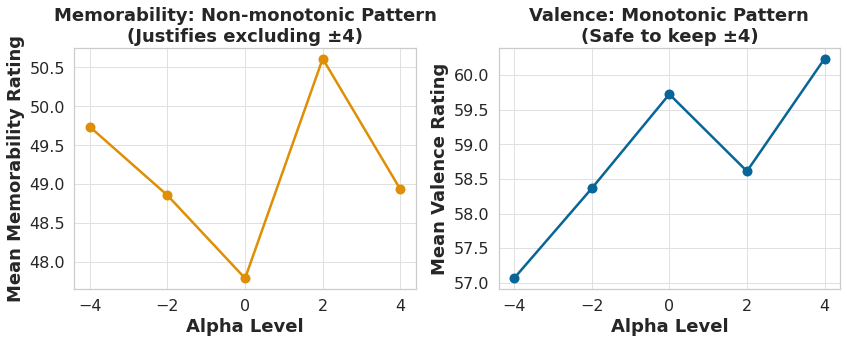

📊 MEMORABILITY MEANS BY ALPHA:
   α = -4: 49.737
   α = -2: 48.856
   α = +0: 47.789
   α = +2: 50.613
   α = +4: 48.933

📊 VALENCE MEANS BY ALPHA:
   α = -4: 57.065
   α = -2: 58.363
   α = +0: 59.724
   α = +2: 58.612
   α = +4: 60.237


In [14]:
# Cell: Visualize A Priori Analysis Results

# Extract detailed results for visualization
mem_alpha_means = results['saturation']['memnet']['alpha_means']
val_alpha_means = results['saturation']['emonet']['alpha_means']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Memorability pattern
ax1.plot(mem_alpha_means.index, mem_alpha_means.values, '-o', color=PALETTE[1], linewidth=2.5, markersize=10)
ax1.set_title('Memorability: Non-monotonic Pattern\n(Justifies excluding ±4)')
ax1.set_xlabel('Alpha Level')
ax1.set_ylabel('Mean Memorability Rating')
ax1.set_xticks([-4, -2, 0, 2, 4])

# Valence pattern  
ax2.plot(val_alpha_means.index, val_alpha_means.values, '-o', color=PALETTE[0], linewidth=2.5, markersize=10)
ax2.set_title('Valence: Monotonic Pattern\n(Safe to keep ±4)')
ax2.set_xlabel('Alpha Level')
ax2.set_ylabel('Mean Valence Rating')
ax2.set_xticks([-4, -2, 0, 2, 4])

plt.tight_layout()
plt.show()

# Print the actual values
print("📊 MEMORABILITY MEANS BY ALPHA:")
for alpha, mean_val in mem_alpha_means.items():
    print(f"   α = {alpha:+2d}: {mean_val:.3f}")

print("\n📊 VALENCE MEANS BY ALPHA:")
for alpha, mean_val in val_alpha_means.items():
    print(f"   α = {alpha:+2d}: {mean_val:.3f}")

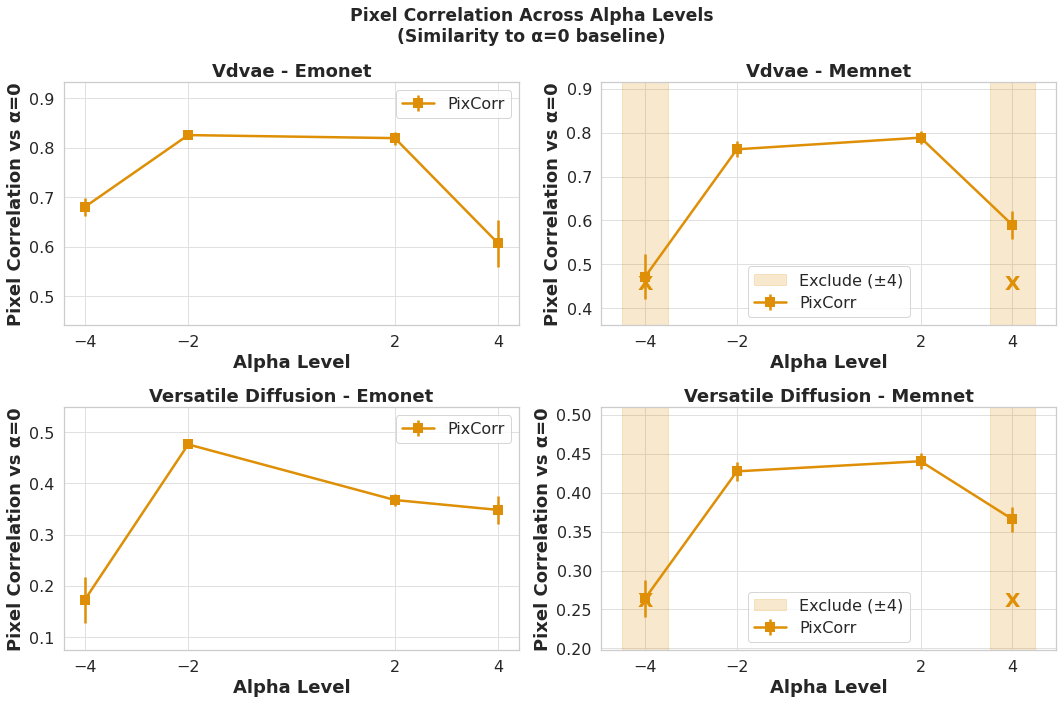

In [15]:
# Cell: Visual Quality Analysis for Alpha Exclusion

from PIL import Image

def load_ssim_pixcorr_data():
    """Load PixCorr summary data for all subjects."""
    
    # Paths from your existing scripts
    pixcorr_root = Path("/home/rothermm/brain-diffuser/results/metrics/pixcorr")
    
    subjects = [1, 2, 5, 7]
    data = []
    
    # Load PixCorr data only
    for subject in subjects:
        pixcorr_file = pixcorr_root / f"subj{subject:02d}" / "summary.csv"
        if pixcorr_file.exists():
            pixcorr_df = pd.read_csv(pixcorr_file)
            pixcorr_df['metric'] = 'PixCorr'
            pixcorr_df['subject'] = f"subj{subject:02d}"
            
            # Extract alpha level from comparison column (e.g., "intra:vdvae:emonet:alpha_-4_vs_alpha_0")
            alpha_extract = pixcorr_df['comparison'].str.extract(r'alpha_([+-]?\d+)_vs_alpha_0')
            pixcorr_df['alpha_level'] = pd.to_numeric(alpha_extract[0], errors='coerce')
            
            # Extract model and network from comparison
            comparison_parts = pixcorr_df['comparison'].str.split(':')
            pixcorr_df['model'] = comparison_parts.str[1] 
            pixcorr_df['network'] = comparison_parts.str[2]
            
            # Filter out rows where alpha_level is NaN (non-alpha comparisons)
            pixcorr_df = pixcorr_df.dropna(subset=['alpha_level'])
            pixcorr_df['alpha_level'] = pixcorr_df['alpha_level'].astype(int)
            
            data.append(pixcorr_df)
    
    if data:
        combined_df = pd.concat(data, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame()

def plot_quality_degradation_by_alpha():
    """Plot PixCorr degradation across alpha levels, highlighting memorability issues."""
    
    df = load_ssim_pixcorr_data()
    if df.empty:
        print("⚠️ No PixCorr data found. Run the metrics scripts first.")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    models = ['vdvae', 'versatile_diffusion']
    networks = ['emonet', 'memnet']
    
    for i, model in enumerate(models):
        for j, network in enumerate(networks):
            ax = axes[i, j]
            
            # Filter data for this model/network (PixCorr only)
            subset = df[(df['model'] == model) & (df['network'] == network) & (df['metric'] == 'PixCorr')]
            
            if subset.empty:
                ax.set_title(f"{model.replace('_', ' ').title()} - {network.title()}")
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
                continue
            
            # Group by alpha and compute mean/sem
            alpha_stats = subset.groupby('alpha_level')['mean'].agg(['mean', 'sem']).reset_index()
            
            # Plot PixCorr only - use colorblind-friendly palette
            ax.errorbar(alpha_stats['alpha_level'], alpha_stats['mean'], 
                      yerr=alpha_stats['sem'], marker='s', color=PALETTE[1], 
                      label='PixCorr', linewidth=2.5, markersize=10)
            
            # Highlight problematic alpha regions for memorability
            if network == 'memnet':
                ax.axvspan(-4.5, -3.5, alpha=0.2, color=PALETTE[1], label='Exclude (±4)')
                ax.axvspan(3.5, 4.5, alpha=0.2, color=PALETTE[1])
                ax.text(-4, ax.get_ylim()[0] + 0.1*(ax.get_ylim()[1]-ax.get_ylim()[0]), 'X', fontsize=20, ha='center', color=PALETTE[1], fontweight='bold')
                ax.text(4, ax.get_ylim()[0] + 0.1*(ax.get_ylim()[1]-ax.get_ylim()[0]), 'X', fontsize=20, ha='center', color=PALETTE[1], fontweight='bold')
            
            ax.set_title(f"{model.replace('_', ' ').title()} - {network.title()}")
            ax.set_xlabel('Alpha Level')
            ax.set_ylabel('Pixel Correlation vs α=0')
            ax.set_xticks([-4, -2, 2, 4])  # Remove 0 since we're comparing to alpha=0
            ax.legend()
            
            # Set y-limits to highlight differences
            if not subset.empty:
                y_min = subset['mean'].min() * 0.9
                y_max = min(subset['mean'].max() * 1.1, 1.0)
                ax.set_ylim(y_min, y_max)
    
    plt.suptitle('Pixel Correlation Across Alpha Levels\n(Similarity to α=0 baseline)', 
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the analysis
plot_quality_degradation_by_alpha()

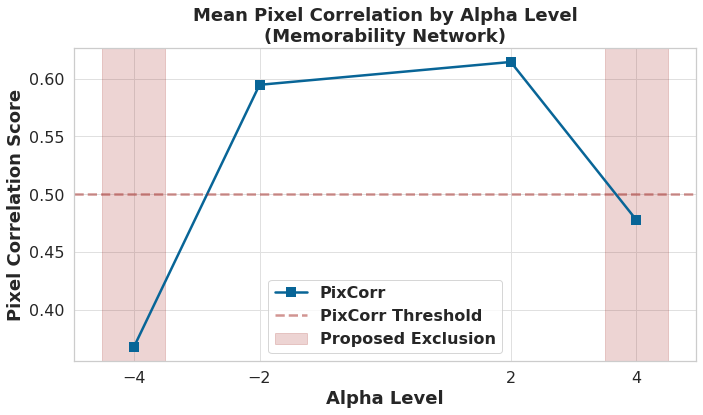

📊 PIXEL CORRELATION ANALYSIS SUMMARY (Memorability Network)

α = -4 (EXCLUDE):
  PixCorr: 0.368 (87.5% below threshold)

α = -2 (INCLUDE):
  PixCorr: 0.595 (50.0% below threshold)

α = +2 (INCLUDE):
  PixCorr: 0.614 (50.0% below threshold)

α = +4 (EXCLUDE):
  PixCorr: 0.478 (50.0% below threshold)


In [25]:
# Cell: Statistical Thresholding for Alpha Exclusion
def analyze_quality_thresholds():
    """Analyze PixCorr thresholds to justify alpha exclusion."""
    
    df = load_ssim_pixcorr_data()
    if df.empty:
        print("⚠️ No PixCorr data found. Run the metrics scripts first.")
        return
    
    # Define quality threshold for PixCorr
    pixcorr_threshold = 0.5  # Below this = poor similarity
    
    # Filter for memorability network (where we exclude ±4)
    memnet_data = df[df['network'] == 'memnet']
    
    if memnet_data.empty:
        print("⚠️ No memorability network data found.")
        return
    
    # Calculate proportion below threshold for each alpha
    quality_analysis = []
    
    for alpha in [-4, -2, 2, 4]:  # Note: alpha=0 not in comparisons for PixCorr
        alpha_data = memnet_data[memnet_data['alpha_level'] == alpha]
        
        if not alpha_data.empty:
            below_threshold = (alpha_data['mean'] < pixcorr_threshold).mean()
            mean_quality = alpha_data['mean'].mean()
            
            quality_analysis.append({
                'alpha': alpha,
                'metric': 'PixCorr',
                'mean_quality': mean_quality,
                'prop_below_threshold': below_threshold,
                'threshold': pixcorr_threshold
            })
    
    if not quality_analysis:
        print("⚠️ No quality analysis data available.")
        return
        
    qa_df = pd.DataFrame(quality_analysis)
    
    # Plot the analysis
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))
    
    # Mean quality by alpha
    ax1.plot(qa_df['alpha'], qa_df['mean_quality'], 
            marker='s', color=PALETTE[0], label='PixCorr', linewidth=2.5, markersize=10)
    
    # Add threshold line
    ax1.axhline(pixcorr_threshold, color=PALETTE[4], linestyle='--', alpha=0.5, 
               label='PixCorr Threshold')
    
    # Highlight extreme alphas
    ax1.axvspan(-4.5, -3.5, alpha=0.2, color=PALETTE[4], label='Proposed Exclusion')
    ax1.axvspan(3.5, 4.5, alpha=0.2, color=PALETTE[4])
    
    ax1.set_title('Mean Pixel Correlation by Alpha Level\n(Memorability Network)')
    ax1.set_xlabel('Alpha Level', fontweight='bold')
    ax1.set_ylabel('Pixel Correlation Score', fontweight='bold')
    ax1.legend(prop={'weight': 'bold'})
    ax1.set_xticks([-4, -2, 2, 4])

    OUTPUT_DIR = "/home/rothermm/brain-diffuser/results/graphs/"
    out_path = os.path.join(OUTPUT_DIR, "exclusion_results.png")
    plt.savefig(out_path, dpi=300)

    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("📊 PIXEL CORRELATION ANALYSIS SUMMARY (Memorability Network)")
    print("=" * 60)
    for alpha in [-4, -2, 2, 4]:
        alpha_subset = qa_df[qa_df['alpha'] == alpha]
        status = "EXCLUDE" if alpha in [-4, 4] else "INCLUDE"
        print(f"\nα = {alpha:+2d} ({status}):")
        
        for _, row in alpha_subset.iterrows():
            print(f"  PixCorr: {row['mean_quality']:.3f} "
                  f"({row['prop_below_threshold']:.1%} below threshold)")

# Run threshold analysis
analyze_quality_thresholds()

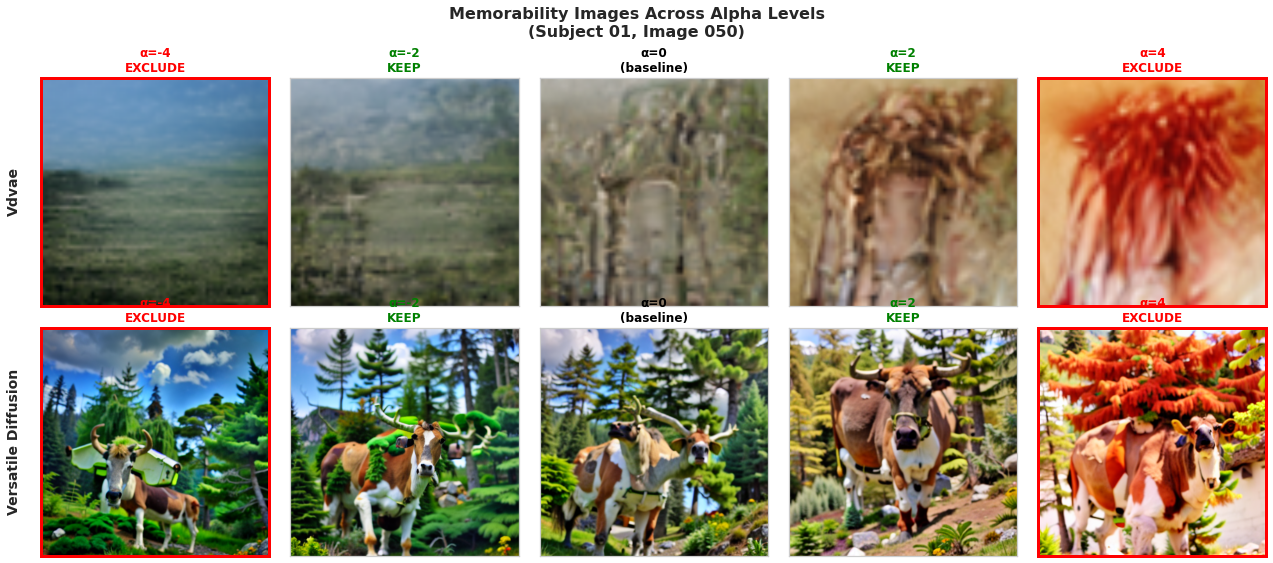


📁 CHECKING IMAGE PATHS (Subject 01, Image 50):

VDVAE:
  α=-4: ✅ EXISTS (simple: 50.png)
  α=-2: ✅ EXISTS (simple: 50.png)
  α=+0: ✅ EXISTS (simple: 50.png)
  α=+2: ✅ EXISTS (simple: 50.png)
  α=+4: ✅ EXISTS (simple: 50.png)

VERSATILE_DIFFUSION:
  α=-4: ✅ EXISTS (simple: 50.png)
  α=-2: ✅ EXISTS (simple: 50.png)
  α=+0: ✅ EXISTS (simple: 50.png)
  α=+2: ✅ EXISTS (simple: 50.png)
  α=+4: ✅ EXISTS (simple: 50.png)


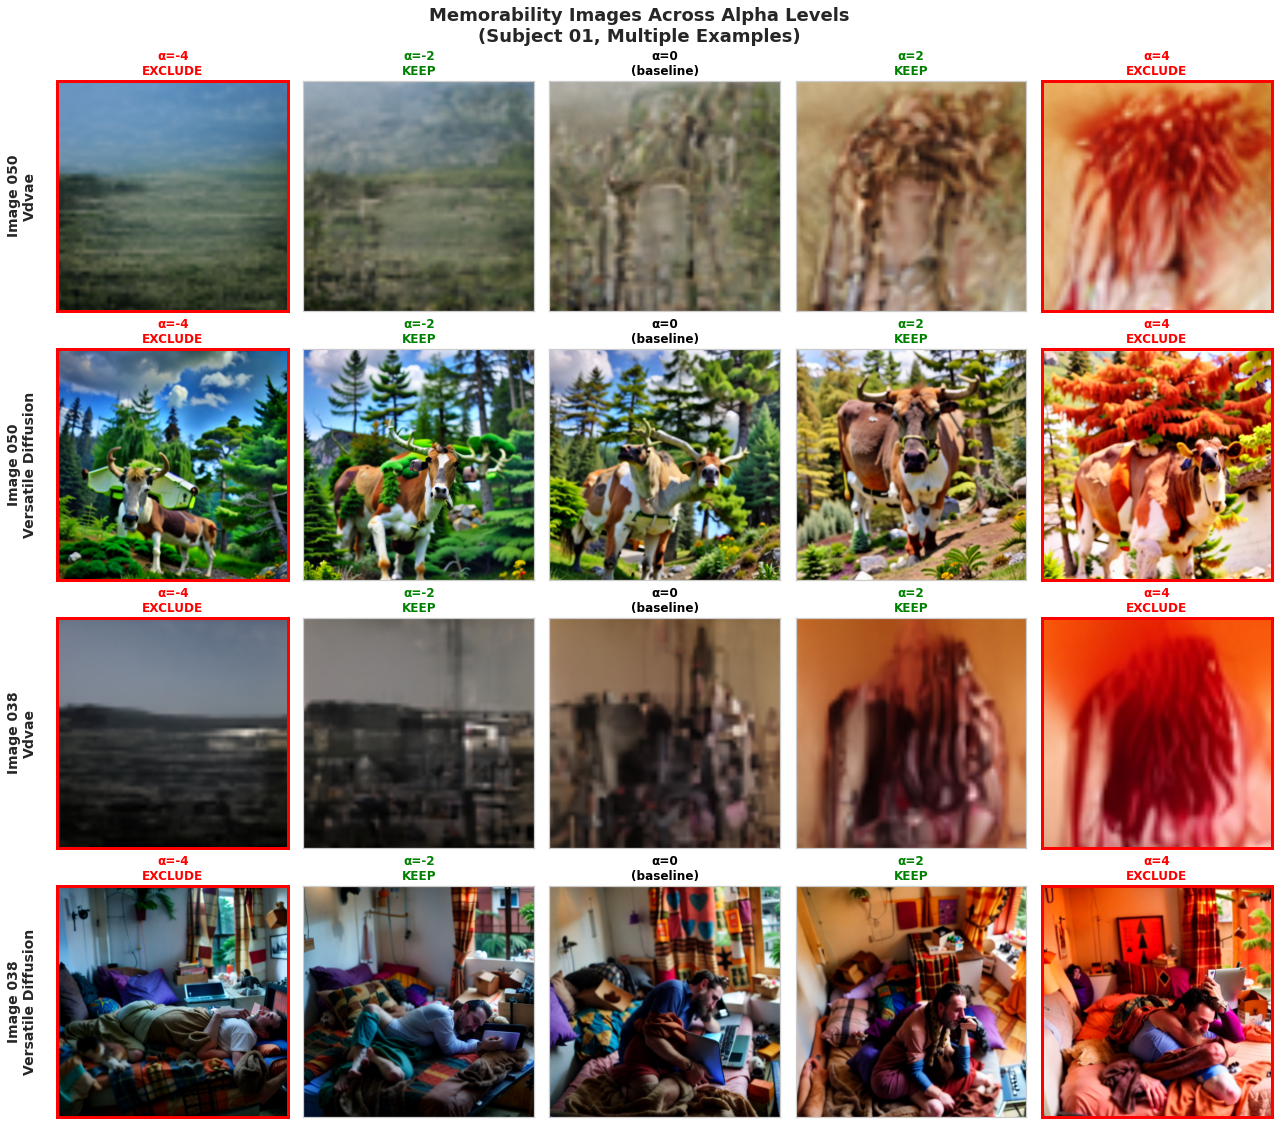


✅ Saved combined figure to: /home/rothermm/brain-diffuser/results/graphs/exclusion_examples_combined.png


In [30]:
def show_extreme_alpha_examples(subject=1, image_idx=0):
    """Display actual images at extreme alpha values to show visual degradation.

    Saves the generated figure to the notebook RESULTS graphs folder as
    `exclusion_examples_{image_idx}.png`.
    """

    base_path = Path("/home/rothermm/brain-diffuser/results")

    fig, axes = plt.subplots(2, 5, figsize=(18, 8))

    models = ['vdvae', 'versatile_diffusion']
    alphas = [-4, -2, 0, 2, 4]

    # Alpha folder mapping - use actual folder names
    alpha_folders = {
        -4: 'alpha_-4', -2: 'alpha_-2', 0: 'alpha_0', 
        2: 'alpha_2', 4: 'alpha_4'
    }

    for row, model in enumerate(models):
        for col, alpha in enumerate(alphas):
            ax = axes[row, col]

            # Try to load memorability network image (where we see issues)
            # Try both zero-padded and non-padded formats
            img_path_padded = base_path / model / f"subj{subject:02d}" / "memnet" / alpha_folders[alpha] / f"{image_idx:03d}.png"
            img_path_simple = base_path / model / f"subj{subject:02d}" / "memnet" / alpha_folders[alpha] / f"{image_idx}.png"

            img_path = img_path_padded if img_path_padded.exists() else img_path_simple

            if img_path.exists():
                img = Image.open(img_path)
                ax.imshow(img)

                # Highlight extreme alphas
                if alpha in [-4, 4]:
                    ax.set_title(f"α={alpha}\nEXCLUDE", color='red', fontweight='bold', fontsize=12)
                    for spine in ax.spines.values():
                        spine.set_color('red')
                        spine.set_linewidth(3)
                else:
                    ax.set_title(f"α={alpha}\nKEEP", color='green', fontsize=12)
                    if alpha == 0:
                        ax.set_title(f"α={alpha}\n(baseline)", color='black', fontsize=12)
            else:
                ax.text(0.5, 0.5, f'Missing\nImage\n{image_idx}', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=10)
                ax.set_title(f"α={alpha}")

            ax.set_xticks([])
            ax.set_yticks([])

        # Add model labels on the left
        axes[row, 0].set_ylabel(f"{model.replace('_', ' ').title()}", 
                               fontsize=14, fontweight='bold', rotation=90, labelpad=20)

    plt.suptitle(f'Memorability Images Across Alpha Levels\n(Subject {subject:02d}, Image {image_idx:03d})', 
                 fontsize=16, fontweight='bold')

    # Ensure output directory exists and save the figure with the requested naming
    OUTPUT_DIR = Path("/home/rothermm/brain-diffuser/results/graphs")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out_path = OUTPUT_DIR / f"exclusion_examples_{image_idx}.png"

    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()

    # Print image paths for verification
    print(f"\n📁 CHECKING IMAGE PATHS (Subject {subject:02d}, Image {image_idx}):")
    print("=" * 60)
    for model in models:
        print(f"\n{model.upper()}:")
        for alpha in alphas:
            img_path_padded = base_path / model / f"subj{subject:02d}" / "memnet" / alpha_folders[alpha] / f"{image_idx:03d}.png"
            img_path_simple = base_path / model / f"subj{subject:02d}" / "memnet" / alpha_folders[alpha] / f"{image_idx}.png"

            if img_path_padded.exists():
                print(f"  α={alpha:+2d}: ✅ EXISTS (padded: {image_idx:03d}.png)")
            elif img_path_simple.exists():
                print(f"  α={alpha:+2d}: ✅ EXISTS (simple: {image_idx}.png)")
            else:
                print(f"  α={alpha:+2d}: ❌ MISSING (tried both {image_idx:03d}.png and {image_idx}.png)")


def show_combined_alpha_examples(subject=1, image_indices=[12, 38]):
    """Display multiple images in a combined figure with panels stacked vertically.
    
    Creates a figure with len(image_indices) panels stacked vertically, each showing
    2 models × 5 alpha levels. Saves to `exclusion_examples_combined.png`.
    """
    
    base_path = Path("/home/rothermm/brain-diffuser/results")
    
    models = ['vdvae', 'versatile_diffusion']
    alphas = [-4, -2, 0, 2, 4]
    
    # Alpha folder mapping
    alpha_folders = {
        -4: 'alpha_-4', -2: 'alpha_-2', 0: 'alpha_0', 
        2: 'alpha_2', 4: 'alpha_4'
    }
    
    n_panels = len(image_indices)
    # Create figure with stacked panels (n_panels × 2 models, 5 alpha columns each)
    fig, axes = plt.subplots(n_panels * 2, 5, figsize=(18, 8 * n_panels))
    
    for panel_idx, image_idx in enumerate(image_indices):
        for model_idx, model in enumerate(models):
            row = panel_idx * 2 + model_idx
            
            for col, alpha in enumerate(alphas):
                ax = axes[row, col]
                
                # Try to load memorability network image
                img_path_padded = base_path / model / f"subj{subject:02d}" / "memnet" / alpha_folders[alpha] / f"{image_idx:03d}.png"
                img_path_simple = base_path / model / f"subj{subject:02d}" / "memnet" / alpha_folders[alpha] / f"{image_idx}.png"
                
                img_path = img_path_padded if img_path_padded.exists() else img_path_simple
                
                if img_path.exists():
                    img = Image.open(img_path)
                    ax.imshow(img)
                    
                    # Highlight extreme alphas
                    if alpha in [-4, 4]:
                        ax.set_title(f"α={alpha}\nEXCLUDE", color='red', fontweight='bold', fontsize=12)
                        for spine in ax.spines.values():
                            spine.set_color('red')
                            spine.set_linewidth(3)
                    else:
                        ax.set_title(f"α={alpha}\nKEEP", color='green', fontsize=12)
                        if alpha == 0:
                            ax.set_title(f"α={alpha}\n(baseline)", color='black', fontsize=12)
                else:
                    ax.text(0.5, 0.5, f'Missing\nImage\n{image_idx}', ha='center', va='center', 
                           transform=ax.transAxes, fontsize=10)
                    ax.set_title(f"α={alpha}")
                
                ax.set_xticks([])
                ax.set_yticks([])
            
            # Add model labels on the left and image index labels
            axes[row, 0].set_ylabel(f"Image {image_idx:03d}\n{model.replace('_', ' ').title()}", 
                                   fontsize=14, fontweight='bold', rotation=90, labelpad=20)
    
    plt.suptitle(f'Memorability Images Across Alpha Levels\n(Subject {subject:02d}, Multiple Examples)', 
                 fontsize=18, fontweight='bold')
    
    # Save combined figure
    OUTPUT_DIR = Path("/home/rothermm/brain-diffuser/results/graphs")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out_path = OUTPUT_DIR / "exclusion_examples_combined.png"
    
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Saved combined figure to: {out_path}")


# Generate individual figures for image 50
show_extreme_alpha_examples(subject=1, image_idx=50)

# Generate combined figure for images 12 and 38
show_combined_alpha_examples(subject=1, image_indices=[50, 38])


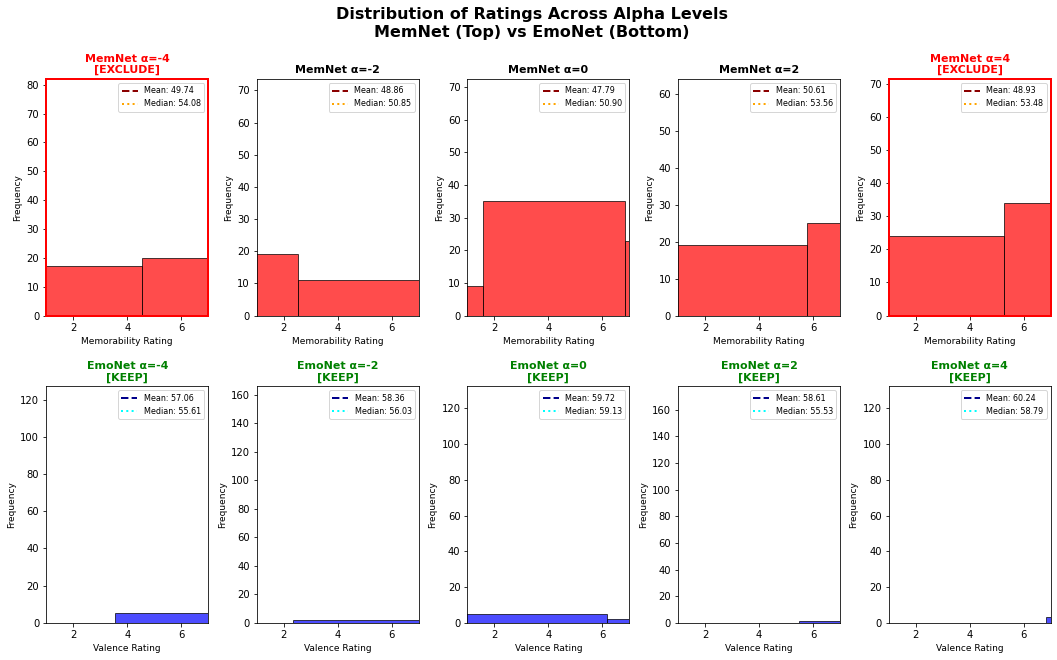

DISTRIBUTION SUMMARY STATISTICS

📊 MEMORABILITY (MemNet):
--------------------------------------------------------------------------------
Alpha    Mean     Median   Std      Skewness   Kurtosis  
--------------------------------------------------------------------------------
[X] α=-4  49.737    54.081    24.067    -0.161      -0.901
    α=-2  48.856    50.847    23.446    -0.058      -0.687
    α=+0  47.789    50.904    23.867    -0.166      -0.758
    α=+2  50.613    53.555    24.625    -0.124      -0.933
[X] α=+4  48.933    53.478    23.953    -0.231      -0.907

📊 VALENCE (EmoNet):
--------------------------------------------------------------------------------
Alpha    Mean     Median   Std      Skewness   Kurtosis  
--------------------------------------------------------------------------------
    α=-4  57.065    55.607    17.093    -0.125      +0.878
    α=-2  58.363    56.029    16.067    +0.121      +0.662
    α=+0  59.724    59.128    17.896    -0.509      +1.382
    α=+2 

In [ ]:
# Cell: Distribution Analysis - Memnet vs Emonet Ratings Across Alphas

def plot_rating_distributions(human_df):
    """Compare distribution of memnet vs emonet ratings across alpha levels."""
    
    alpha_map = {
        'valence-4': -4, 'valence-2': -2, 'alpha0': 0, 'valence+2': 2, 'valence+4': 4,
        'mem-4': -4, 'mem-2': -2, 'mem+2': 2, 'mem+4': 4
    }
    
    # Prepare data for both networks
    emonet_conditions = ['valence-4', 'valence-2', 'alpha0', 'valence+2', 'valence+4']
    memnet_conditions = ['mem-4', 'mem-2', 'alpha0', 'mem+2', 'mem+4']
    
    emonet_df = human_df[human_df['Condition'].isin(emonet_conditions)].copy()
    emonet_df['Alpha'] = emonet_df['Condition'].map(alpha_map)
    emonet_df['Network'] = 'EmoNet (Valence)'
    emonet_df['Rating'] = emonet_df['ValenceRating']
    
    memnet_df = human_df[human_df['Condition'].isin(memnet_conditions)].copy()
    memnet_df['Alpha'] = memnet_df['Condition'].map(alpha_map)
    memnet_df['Network'] = 'MemNet (Memorability)'
    memnet_df['Rating'] = memnet_df['MemorabilityRating']
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 5, hspace=0.3, wspace=0.3)
    
    alphas = [-4, -2, 0, 2, 4]
    
    # Top row: Memnet distributions
    for i, alpha in enumerate(alphas):
        ax = fig.add_subplot(gs[0, i])
        
        mem_data = memnet_df[memnet_df['Alpha'] == alpha]['Rating'].dropna()
        
        if len(mem_data) > 0:
            ax.hist(mem_data, bins=20, alpha=0.7, color=PALETTE[1], edgecolor='black')
            ax.axvline(mem_data.mean(), color=PALETTE[1], linestyle='--', linewidth=2.5, label=f'Mean: {mem_data.mean():.2f}')
            ax.axvline(mem_data.median(), color=PALETTE[3], linestyle=':', linewidth=2.5, label=f'Median: {mem_data.median():.2f}')
            
            # Highlight extreme alphas
            if alpha in [-4, 4]:
                ax.set_title(f'MemNet α={alpha}\n[EXCLUDE]', color=PALETTE[1], fontweight='bold')
                for spine in ax.spines.values():
                    spine.set_color(PALETTE[1])
                    spine.set_linewidth(2)
            else:
                ax.set_title(f'MemNet α={alpha}', fontweight='bold')
            
            ax.set_xlabel('Memorability Rating')
            ax.set_ylabel('Frequency')
            ax.legend()
            ax.set_xlim(1, 7)
        else:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
    
    # Bottom row: Emonet distributions
    for i, alpha in enumerate(alphas):
        ax = fig.add_subplot(gs[1, i])
        
        emo_data = emonet_df[emonet_df['Alpha'] == alpha]['Rating'].dropna()
        
        if len(emo_data) > 0:
            ax.hist(emo_data, bins=20, alpha=0.7, color=PALETTE[0], edgecolor='black')
            ax.axvline(emo_data.mean(), color=PALETTE[0], linestyle='--', linewidth=2.5, label=f'Mean: {emo_data.mean():.2f}')
            ax.axvline(emo_data.median(), color=PALETTE[2], linestyle=':', linewidth=2.5, label=f'Median: {emo_data.median():.2f}')
            
            ax.set_title(f'EmoNet α={alpha}\n[KEEP]', color=PALETTE[2], fontweight='bold')
            ax.set_xlabel('Valence Rating')
            ax.set_ylabel('Frequency')
            ax.legend()
            ax.set_xlim(1, 7)
        else:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
    
    plt.suptitle('Distribution of Ratings Across Alpha Levels\nMemNet (Top) vs EmoNet (Bottom)', 
                 fontweight='bold')
    plt.show()
    
    # Print summary statistics
    print("=" * 80)
    print("DISTRIBUTION SUMMARY STATISTICS")
    print("=" * 80)
    
    print("\n📊 MEMORABILITY (MemNet):")
    print("-" * 80)
    print(f"{'Alpha':<8} {'Mean':<8} {'Median':<8} {'Std':<8} {'Skewness':<10} {'Kurtosis':<10}")
    print("-" * 80)
    
    from scipy.stats import skew, kurtosis
    
    for alpha in alphas:
        mem_data = memnet_df[memnet_df['Alpha'] == alpha]['Rating'].dropna()
        if len(mem_data) > 0:
            status = "[X]" if alpha in [-4, 4] else "   "
            print(f"{status} α={alpha:+2d}  {mem_data.mean():.3f}    {mem_data.median():.3f}    "
                  f"{mem_data.std():.3f}    {skew(mem_data):+.3f}      {kurtosis(mem_data):+.3f}")
    
    print("\n📊 VALENCE (EmoNet):")
    print("-" * 80)
    print(f"{'Alpha':<8} {'Mean':<8} {'Median':<8} {'Std':<8} {'Skewness':<10} {'Kurtosis':<10}")
    print("-" * 80)
    
    for alpha in alphas:
        emo_data = emonet_df[emonet_df['Alpha'] == alpha]['Rating'].dropna()
        if len(emo_data) > 0:
            print(f"    α={alpha:+2d}  {emo_data.mean():.3f}    {emo_data.median():.3f}    "
                  f"{emo_data.std():.3f}    {skew(emo_data):+.3f}      {kurtosis(emo_data):+.3f}")
    
    print("=" * 80)

# Load data and plot
human_df_detrended = pd.read_csv("/home/rothermm/brain-diffuser/data/human_data/human_df_detrended.csv")
plot_rating_distributions(human_df_detrended)

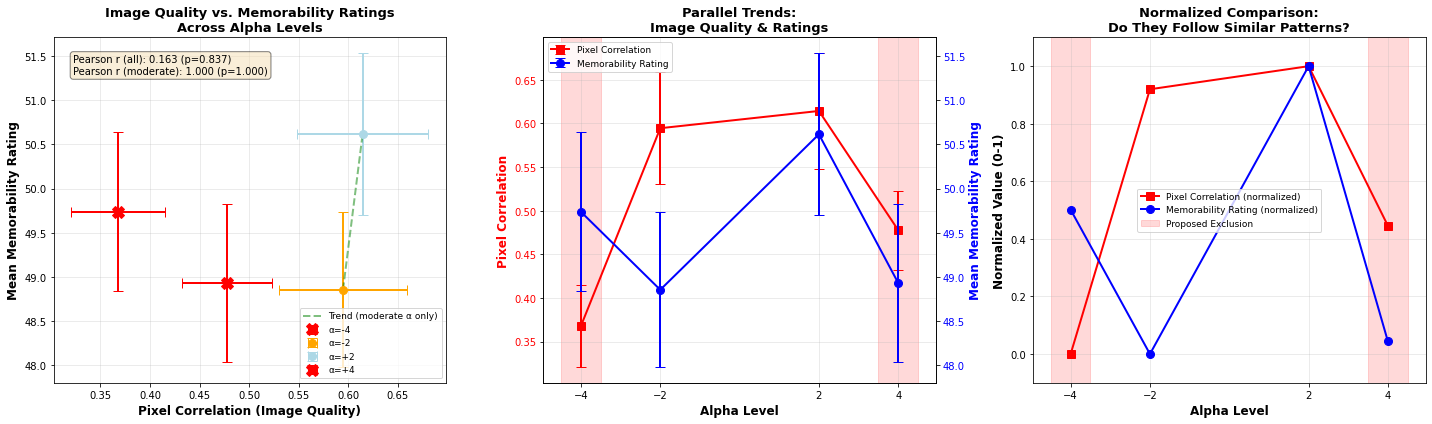

PIXEL CORRELATION vs MEMORABILITY RATING ANALYSIS

Alpha    PixCorr      PixCorr SEM    MemNet       MemNet SEM     Status    
--------------------------------------------------------------------------------
α=-4     0.3681       0.0472         49.7368       0.8969         EXCLUDE
α=-2     0.5946       0.0640         48.8557       0.8738         INCLUDE
α=+2     0.6144       0.0663         50.6131       0.9177         INCLUDE
α=+4     0.4778       0.0454         48.9325       0.8927         EXCLUDE

KEY INSIGHT:
If PixCorr and MemNet ratings diverge at extreme alphas, it suggests
that image quality degradation affects memorability judgments.


In [ ]:
# Cell: Relationship Between Image Quality (PixCorr) and Memnet Ratings

def plot_pixcorr_vs_memnet_ratings():
    """Analyze relationship between pixel correlation and mean memnet scores at different alphas."""
    
    # Load pixel correlation data
    pixcorr_df = load_ssim_pixcorr_data()
    
    if pixcorr_df.empty:
        print("⚠️ No PixCorr data found. Run the metrics scripts first.")
        return
    
    # Load human ratings
    human_df = pd.read_csv("/home/rothermm/brain-diffuser/data/human_data/human_df_detrended.csv")
    
    # Prepare memnet data
    alpha_map = {
        'mem-4': -4, 'mem-2': -2, 'alpha0': 0, 'mem+2': 2, 'mem+4': 4
    }
    
    memnet_conditions = ['mem-4', 'mem-2', 'alpha0', 'mem+2', 'mem+4']
    memnet_df = human_df[human_df['Condition'].isin(memnet_conditions)].copy()
    memnet_df['Alpha'] = memnet_df['Condition'].map(alpha_map)
    
    # Calculate mean memnet ratings by alpha
    memnet_means = memnet_df.groupby('Alpha')['MemorabilityRating'].agg(['mean', 'std', 'sem']).reset_index()
    
    # Filter pixcorr for memnet network
    pixcorr_memnet = pixcorr_df[pixcorr_df['network'] == 'memnet'].copy()
    
    # Calculate mean pixcorr by alpha (across models and subjects)
    pixcorr_means = pixcorr_memnet.groupby('alpha_level')['mean'].agg(['mean', 'std', 'sem']).reset_index()
    pixcorr_means.columns = ['Alpha', 'PixCorr_mean', 'PixCorr_std', 'PixCorr_sem']
    
    # Merge the two datasets
    combined = pd.merge(memnet_means, pixcorr_means, on='Alpha', how='inner')
    
    if combined.empty:
        print("⚠️ No overlapping data between PixCorr and MemNet ratings.")
        return
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Plot 1: Scatter plot with error bars
    ax1 = axes[0]
    
    # Color code by alpha level using colorblind-friendly palette
    alpha_colors = {-4: PALETTE[1], -2: PALETTE[3], 0: PALETTE[5], 2: PALETTE[7], 4: PALETTE[1]}
    
    for _, row in combined.iterrows():
        alpha = int(row['Alpha'])
        color = alpha_colors.get(alpha, PALETTE[5])
        marker = 'X' if alpha in [-4, 4] else 'o'
        
        ax1.errorbar(row['PixCorr_mean'], row['mean'], 
                    xerr=row['PixCorr_sem'], yerr=row['sem'],
                    fmt=marker, color=color, markersize=12 if alpha in [-4, 4] else 10,
                    linewidth=2.5, label=f'α={alpha:+d}')
    
    # Add correlation line (excluding extreme alphas)
    moderate_data = combined[~combined['Alpha'].isin([-4, 4])]
    if len(moderate_data) > 1:
        from scipy.stats import pearsonr, spearmanr
        
        # Fit line to moderate alphas
        z = np.polyfit(moderate_data['PixCorr_mean'], moderate_data['mean'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(moderate_data['PixCorr_mean'].min(), moderate_data['PixCorr_mean'].max(), 100)
        ax1.plot(x_line, p(x_line), color=PALETTE[2], linestyle='--', alpha=0.7, linewidth=2.5, label='Trend (moderate α only)')
        
        # Calculate correlations
        r_all, p_all = pearsonr(combined['PixCorr_mean'], combined['mean'])
        r_mod, p_mod = pearsonr(moderate_data['PixCorr_mean'], moderate_data['mean'])
        
        ax1.text(0.05, 0.95, f'Pearson r (all): {r_all:.3f} (p={p_all:.3f})\n'
                            f'Pearson r (moderate): {r_mod:.3f} (p={p_mod:.3f})',
                transform=ax1.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax1.set_xlabel('Pixel Correlation (Image Quality)', fontweight='bold')
    ax1.set_ylabel('Mean Memorability Rating', fontweight='bold')
    ax1.set_title('Image Quality vs. Memorability Ratings\nAcross Alpha Levels', fontweight='bold')
    ax1.legend(loc='lower right')
    
    # Plot 2: Dual Y-axis showing both metrics across alpha
    ax2 = axes[1]
    ax2_twin = ax2.twinx()
    
    # Sort by alpha for proper line plot
    combined_sorted = combined.sort_values('Alpha')
    
    # Plot PixCorr on left axis
    line1 = ax2.errorbar(combined_sorted['Alpha'], combined_sorted['PixCorr_mean'],
                         yerr=combined_sorted['PixCorr_sem'], 
                         color=PALETTE[1], marker='s', linewidth=2.5, markersize=10,
                         label='Pixel Correlation')
    
    # Plot MemNet ratings on right axis
    line2 = ax2_twin.errorbar(combined_sorted['Alpha'], combined_sorted['mean'],
                               yerr=combined_sorted['sem'],
                               color=PALETTE[0], marker='o', linewidth=2.5, markersize=10,
                               label='Memorability Rating')
    
    # Highlight extreme alphas
    ax2.axvspan(-4.5, -3.5, alpha=0.15, color=PALETTE[1])
    ax2.axvspan(3.5, 4.5, alpha=0.15, color=PALETTE[1])
    
    ax2.set_xlabel('Alpha Level', fontweight='bold')
    ax2.set_ylabel('Pixel Correlation', color=PALETTE[1], fontweight='bold')
    ax2_twin.set_ylabel('Mean Memorability Rating', color=PALETTE[0], fontweight='bold')
    ax2.set_title('Parallel Trends:\nImage Quality & Ratings', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=PALETTE[1])
    ax2_twin.tick_params(axis='y', labelcolor=PALETTE[0])
    ax2.set_xticks(combined_sorted['Alpha'])
    
    # Add legend
    lines = [line1, line2]
    labels = ['Pixel Correlation', 'Memorability Rating']
    ax2.legend(lines, labels, loc='upper left')
    
    # Plot 3: Normalized comparison (scale both to 0-1)
    ax3 = axes[2]
    
    # Normalize both metrics to 0-1 range
    combined_sorted['PixCorr_norm'] = (combined_sorted['PixCorr_mean'] - combined_sorted['PixCorr_mean'].min()) / \
                                       (combined_sorted['PixCorr_mean'].max() - combined_sorted['PixCorr_mean'].min())
    combined_sorted['MemNet_norm'] = (combined_sorted['mean'] - combined_sorted['mean'].min()) / \
                                      (combined_sorted['mean'].max() - combined_sorted['mean'].min())
    
    ax3.plot(combined_sorted['Alpha'], combined_sorted['PixCorr_norm'], 
            '-s', color=PALETTE[1], linewidth=2.5, markersize=10, label='Pixel Correlation (normalized)')
    ax3.plot(combined_sorted['Alpha'], combined_sorted['MemNet_norm'],
            '-o', color=PALETTE[0], linewidth=2.5, markersize=10, label='Memorability Rating (normalized)')
    
    # Highlight extreme alphas
    ax3.axvspan(-4.5, -3.5, alpha=0.15, color=PALETTE[1], label='Proposed Exclusion')
    ax3.axvspan(3.5, 4.5, alpha=0.15, color=PALETTE[1])
    
    ax3.set_xlabel('Alpha Level', fontweight='bold')
    ax3.set_ylabel('Normalized Value (0-1)', fontweight='bold')
    ax3.set_title('Normalized Comparison:\nDo They Follow Similar Patterns?', fontweight='bold')
    ax3.set_xticks(combined_sorted['Alpha'])
    ax3.legend()
    ax3.set_ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("=" * 80)
    print("PIXEL CORRELATION vs MEMORABILITY RATING ANALYSIS")
    print("=" * 80)
    print(f"\n{'Alpha':<8} {'PixCorr':<12} {'PixCorr SEM':<14} {'MemNet':<12} {'MemNet SEM':<14} {'Status':<10}")
    print("-" * 80)
    
    for _, row in combined_sorted.iterrows():
        alpha = int(row['Alpha'])
        status = "EXCLUDE" if alpha in [-4, 4] else "INCLUDE"
        print(f"α={alpha:+2d}     {row['PixCorr_mean']:.4f}       {row['PixCorr_sem']:.4f}         "
              f"{row['mean']:.4f}       {row['sem']:.4f}         {status}")
    
    print("\n" + "=" * 80)
    print("KEY INSIGHT:")
    print("If PixCorr and MemNet ratings diverge at extreme alphas, it suggests")
    print("that image quality degradation affects memorability judgments.")
    print("=" * 80)

# Run the analysis
plot_pixcorr_vs_memnet_ratings()